In [1]:
from langchain_core.tools.retriever import create_retriever_tool

In [ ]:
create_retriever_tool()

In [7]:
import json

In [18]:
import os

In [21]:
os.getcwd()

'/Users/kyeongchanlee/projects/GuideRec'

In [20]:
os.chdir('../../')

In [22]:
from utils import graphdb_driver

/Users/kyeongchanlee/projects/GuideRec/llm_response/get_llm_model.py:20: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(


In [64]:
from neo4j.graph import Node, Relationship
from pyvis.network import Network
import streamlit.components.v1 as components
from utils import graphdb_driver

def run_cypher_and_extract_elements(graphdb_driver, cypher: str):
    result = graphdb_driver.execute_query(cypher)
    nodes = set()
    edges = []
    for record in result.records:
        for value in record.values():
            if isinstance(value, Node):
                nodes.add(value)
            elif isinstance(value, Relationship):
                edges.append((value.start_node.id, value.end_node.id, value.type))
    return list(nodes), edges

def draw_graph_pyvis(nodes, edges):
    net = Network(height="600px", width="100%", notebook=False)
    for node in nodes:
        net.add_node(node.id, label=node.get("MCT_NM") or node.get("name") or str(node.id), title=str(dict(node)))
    for start, end, rel in edges:
        net.add_edge(start, end, label=rel)
    net.save_graph("graph.html")
    components.html(open("graph.html", "r", encoding="utf-8").read(), height=650)

In [71]:
cypher="""MATCH (a:ATTR)
WHERE a.AREA_NM CONTAINS "신화월드"
WITH a.latitude AS swLat, a.longitude AS swLon

MATCH (rg:Region)-[r1:HAS_STORE]->(s:STORE)-[r2:HAS_VISIT_KEYWORD]->(v:Visit_with)
WHERE s.MCT_TYPE = '가정식'
  AND ANY(menuItem IN split(s.menu, ", ") 
          WHERE toInteger(apoc.text.regreplace(menuItem, ".*:(\\d+)", "$1")) <= 10000)
  AND v.keyword CONTAINS '혼자'

WITH s, rg, v, r1, r2, swLat, swLon, s.latitude AS storeLat, s.longitude AS storeLon

RETURN s, rg, v, r1, r2, 
       s.pk AS pk, 
       s.MCT_NM AS RestaurantName, 
       s.ADDR AS Address, 
       s.menu AS Menu, 
       point.distance(point({latitude: swLat, longitude: swLon}), point({latitude: storeLat, longitude: storeLon})) AS Distance_from_Jeju_Shinhwa_World
ORDER BY Distance_from_Jeju_Shinhwa_World ASC
LIMIT 500
"""

In [72]:
nodes, edges = run_cypher_and_extract_elements(graphdb_driver, cypher)

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated function. ('apoc.text.regreplace' has been replaced by 'apoc.text.replace')} {position: line: 8, column: 27, offset: 272} for query: 'MATCH (a:ATTR)\nWHERE a.AREA_NM CONTAINS "신화월드"\nWITH a.latitude AS swLat, a.longitude AS swLon\n\nMATCH (rg:Region)-[r1:HAS_STORE]->(s:STORE)-[r2:HAS_VISIT_KEYWORD]->(v:Visit_with)\nWHERE s.MCT_TYPE = \'가정식\'\n  AND ANY(menuItem IN split(s.menu, ", ") \n          WHERE toInteger(apoc.text.regreplace(menuItem, ".*:(\\d+)", "$1")) <= 10000)\n  AND v.keyword CONTAINS \'혼자\'\n\nWITH s, rg, v, r1, r2, swLat, swLon, s.latitude AS storeLat, s.longitude AS storeLon\n\nRETURN s, rg, v, r1, r2, \n       s.pk AS pk, \n       s.MCT_NM AS RestaurantName, \n       s.ADDR AS Address, \n       s.menu AS M

In [73]:
len(nodes)

382

In [74]:
len(edges)

668

In [75]:
draw_graph_pyvis(nodes, edges)

/var/folders/l8/9t2cbzsj2z9cvyqt_86qj66h0000gn/T/ipykernel_67796/561535963.py:21: DeprecationWarning: `id` is deprecated, use `element_id` instead
  net.add_node(node.id, label=node.get("MCT_NM") or node.get("name") or str(node.id), title=str(dict(node)))
2025-06-29 04:41:03.670 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-29 04:41:03.671 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [78]:
net = Network(height="600px", width="100%", notebook=False)
for node in nodes:
    net.add_node(node.id, label=node.get("MCT_NM") or node.get("name") or str(node.id), title=str(dict(node)))
for start, end, rel in edges:
    net.add_edge(start, end, label=rel)
net.save_graph("graph.html")
components.html(open("graph.html", "r", encoding="utf-8").read(), height=650)

/var/folders/l8/9t2cbzsj2z9cvyqt_86qj66h0000gn/T/ipykernel_67796/2382667627.py:3: DeprecationWarning: `id` is deprecated, use `element_id` instead
  net.add_node(node.id, label=node.get("MCT_NM") or node.get("name") or str(node.id), title=str(dict(node)))
2025-06-29 04:42:20.189 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-29 04:42:20.189 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [79]:
net.save_graph("graph.html")

In [80]:
import webbrowser
webbrowser.open("graph.html")

True

In [81]:
components.html(open("graph.html", "r", encoding="utf-8").read(), height=650)


2025-06-29 04:42:56.301 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-29 04:42:56.303 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

/var/folders/l8/9t2cbzsj2z9cvyqt_86qj66h0000gn/T/ipykernel_67796/3996768149.py:9: DeprecationWarning: `id` is deprecated, use `element_id` instead
  G.add_node(node.id, label=node.get("MCT_NM") or node.get("name"))


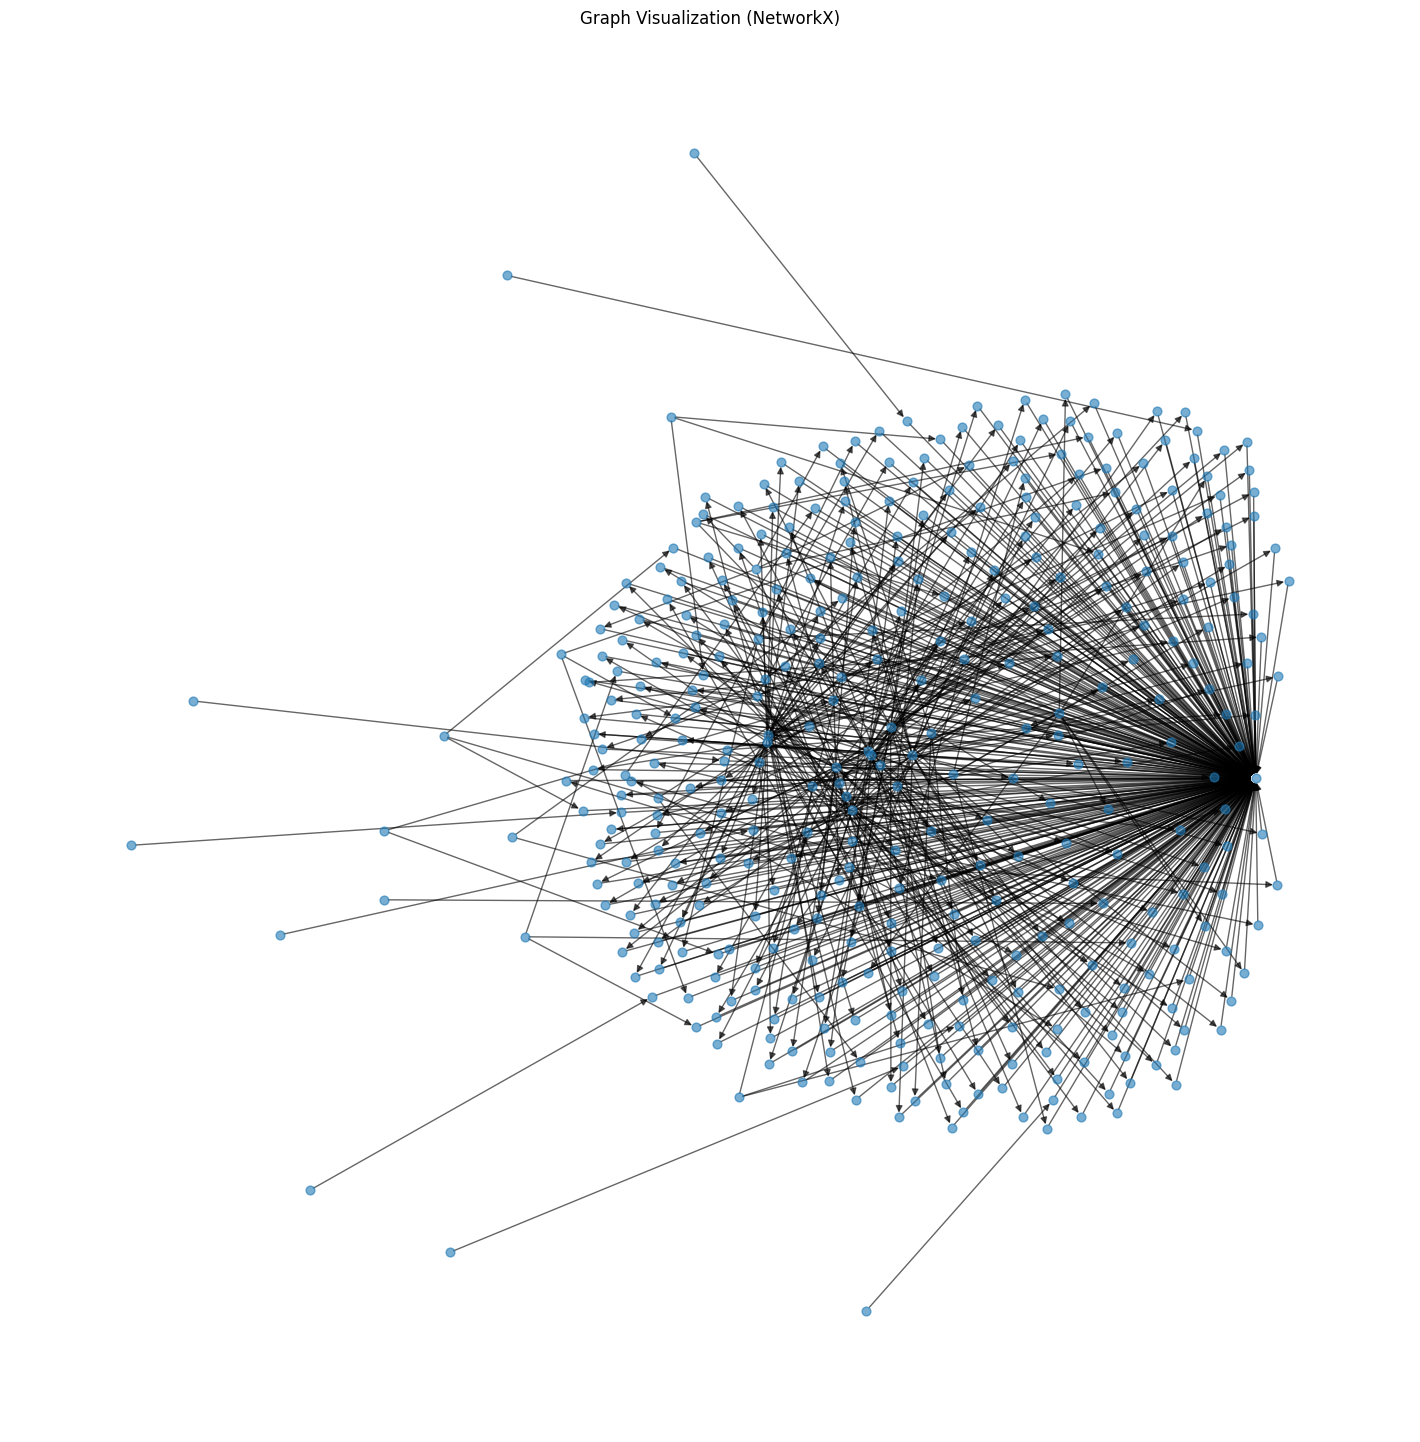

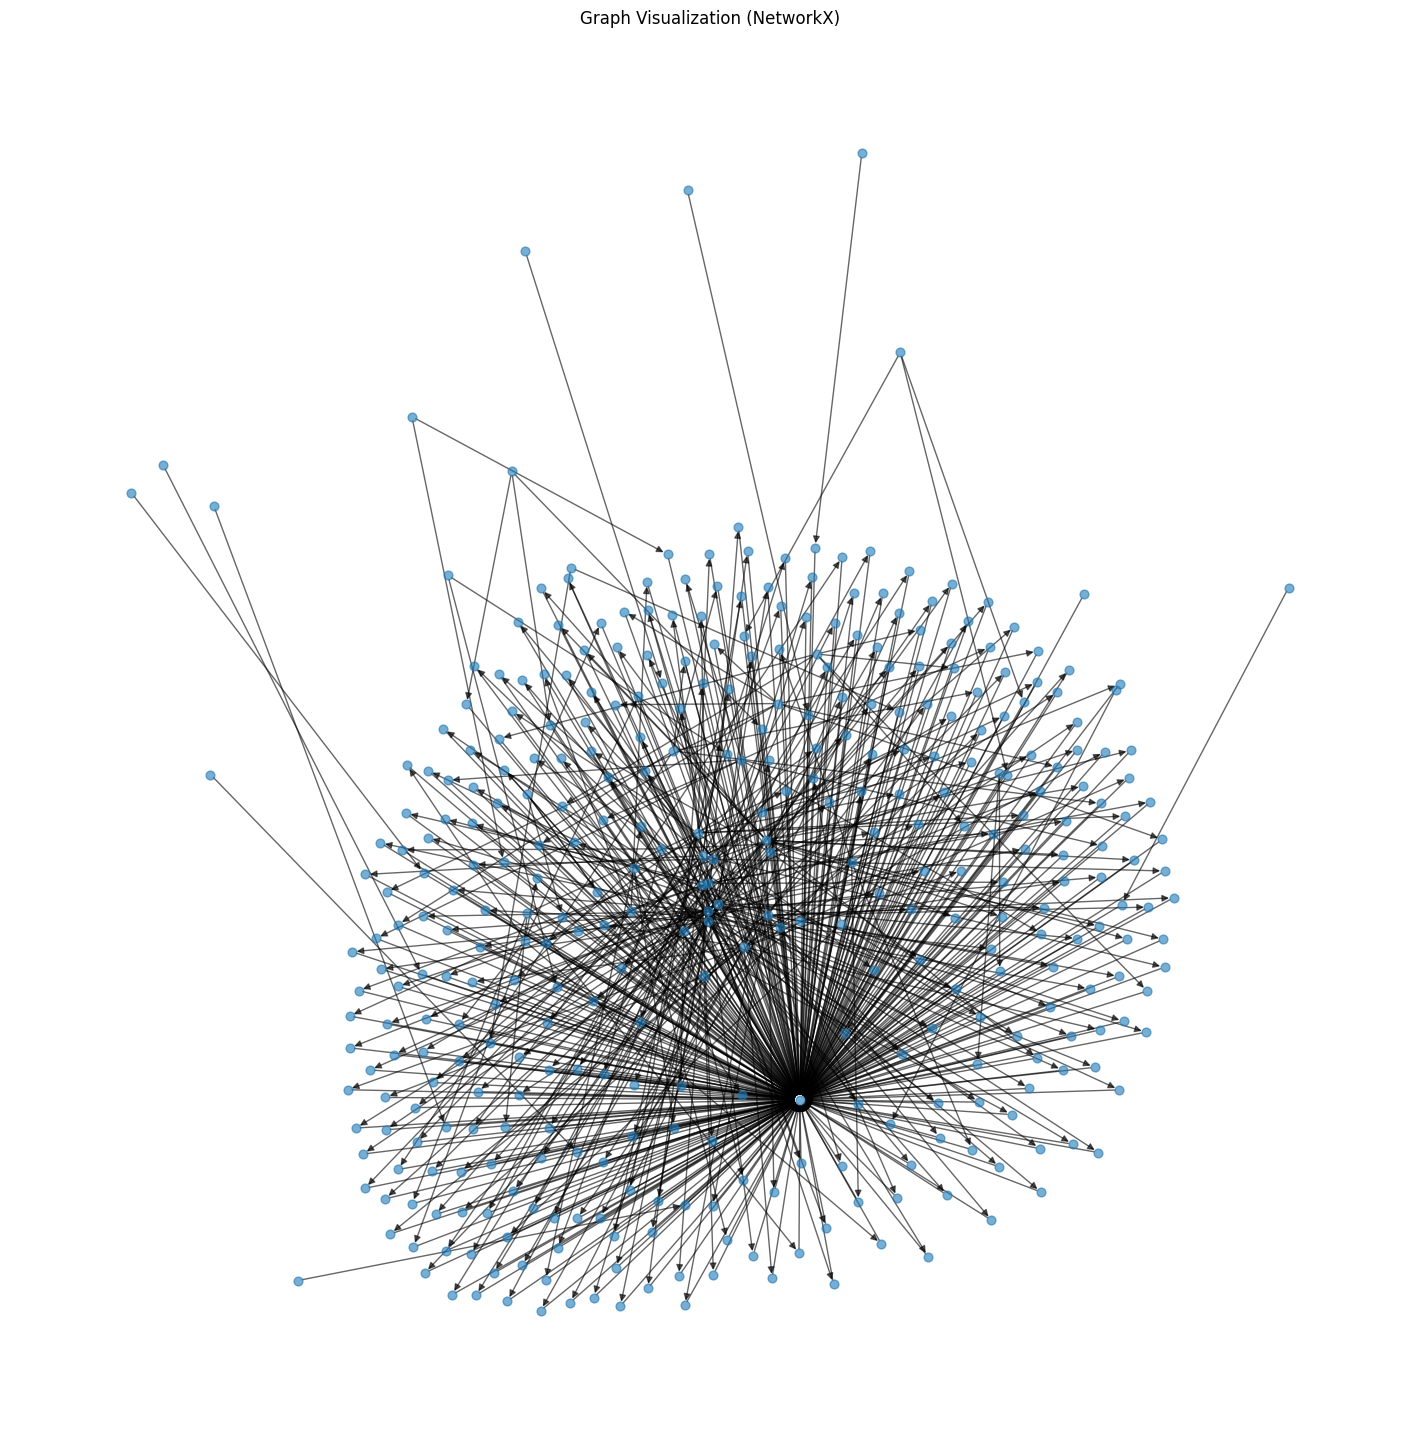

In [83]:
%matplotlib inline

import networkx as nx
import matplotlib.pyplot as plt

def draw_with_networkx(nodes, edges):
    G = nx.DiGraph()
    for node in nodes:
        G.add_node(node.id, label=node.get("MCT_NM") or node.get("name"))
    for start, end, rel in edges:
        G.add_edge(start, end, label=rel)

    plt.figure(figsize=(14, 14))
    pos = nx.spring_layout(G, k=0.15)
    nx.draw(G, pos, with_labels=False, node_size=40, alpha=0.6)
    plt.title("Graph Visualization (NetworkX)")
    plt.show()

draw_with_networkx(nodes, edges)
